# CreditShield – Loan Applicant Credit Risk Analysis (ML)
# Goal: To predict the credit risk of loan applicants based on their financial history and behavior using k-NN Classification.

## 1. Data Exploration & Preprocessing

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel(r"C:\Users\Admin\OneDrive\Desktop\ML_Projects\1768299714153-ML Project - KNN Loan Applicant Credit Risk Analysis U 16955473070.xlsx")
data

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1
...,...,...,...,...,...,...,...
8990,30.80,3,3,0.596748,763,0,0
8991,31.83,3,6,0.986793,532,0,0
8992,32.67,2,5,0.628330,590,0,0
8993,37.00,3,3,0.797193,812,0,0


In [3]:
data.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

In [5]:
data.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,38.808202,2.131073,4.288160,0.831183,752.626570,0.322068,1.162757
std,10.203371,0.892141,1.269416,0.490216,67.645792,0.914998,2.352798
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662147,730.000000,0.000000,0.000000
50%,37.200000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.400000,3.000000,5.000000,0.930908,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


In [9]:
data.columns = data.columns.str.replace(" ","_")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


## 2. Visualizing Outliers

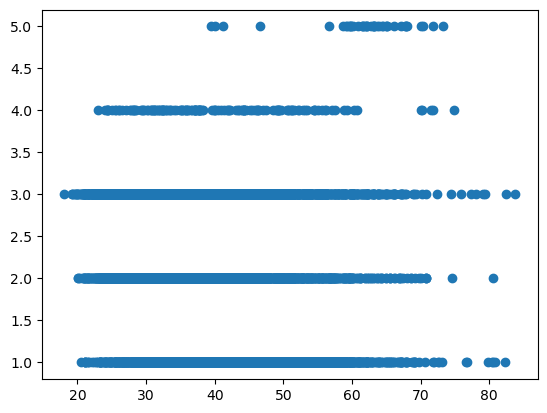

In [10]:
plt.scatter(data["Age"],data["Total_Work_Experience"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18f319f6210>,
 'caps': [<matplotlib.lines.Line2D at 0x18f319f6490>,
 'boxes': [<matplotlib.lines.Line2D at 0x18f319f60d0>],
 'medians': [<matplotlib.lines.Line2D at 0x18f319f6710>],
 'fliers': [<matplotlib.lines.Line2D at 0x18f319f6850>],
 'means': []}

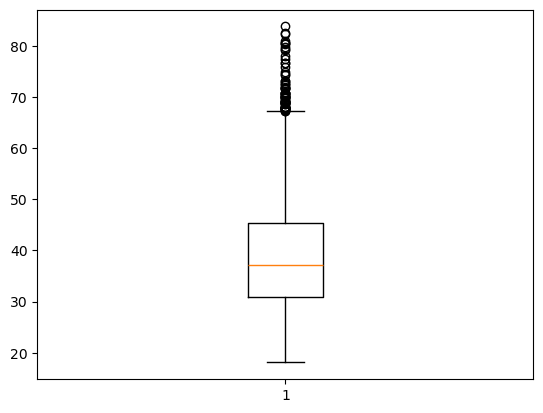

In [11]:
plt.boxplot(data["Age"])

{'whiskers': [<matplotlib.lines.Line2D at 0x18f31a66210>,
 'caps': [<matplotlib.lines.Line2D at 0x18f31a66490>,
 'boxes': [<matplotlib.lines.Line2D at 0x18f31a660d0>],
 'medians': [<matplotlib.lines.Line2D at 0x18f31a66710>],
 'fliers': [<matplotlib.lines.Line2D at 0x18f31a66850>],
 'means': []}

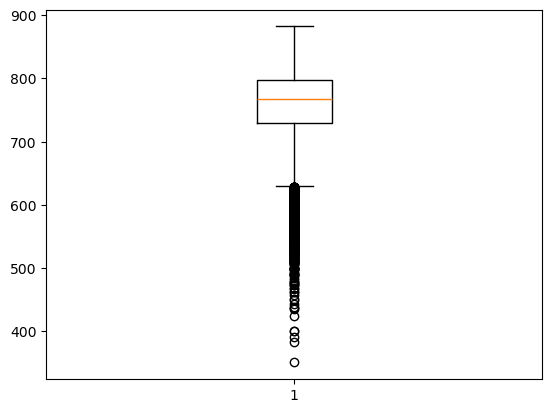

In [12]:
plt.boxplot(data["Cibil_score"])

## 3. k-NN Classification Model

In [13]:
x = data.drop("Total_bounces_past12months",axis=1)
y = data["Total_bounces_past12months"]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
model = KNeighborsClassifier()

In [18]:
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
model.score(x_train,y_train)

0.6787103946637021

In [20]:
model.score(x_test,y_test)

0.6470261256253474

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
ypri = model.predict(x_test)
ypri

array([1, 0, 0, ..., 0, 0, 0])

In [23]:
accuracy_score(y_test,ypri)

0.6470261256253474

## 4. Hyperparameter Tuning (K-Value Optimization)

In [24]:
train_score = []
test_score = []

for k in range(1,15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)

    train_score.append(knn.score(x_train,y_train))
    test_score.append(knn.score(x_test,y_test))

In [25]:
for i in range(1,15):
    print("k=",i,
         "train socre = ",train_score[i-1],
         "test socre = ",test_score[i-1],
         )

k= 1 train socre =  1.0 test socre =  0.546414674819344
k= 2 train socre =  0.74082823790995 test socre =  0.6259032795997777
k= 3 train socre =  0.7066425792106726 test socre =  0.6270150083379655
k= 4 train socre =  0.6862145636464703 test socre =  0.6370205669816564
k= 5 train socre =  0.6787103946637021 test socre =  0.6470261256253474
k= 6 train socre =  0.6681489716509171 test socre =  0.6531406336853808
k= 7 train socre =  0.6628682601445247 test socre =  0.6498054474708171
k= 8 train socre =  0.6607837687604224 test socre =  0.6542523624235687
k= 9 train socre =  0.6574485825458588 test socre =  0.6559199555308505
k= 10 train socre =  0.656058921623124 test socre =  0.6592551417454141
k= 11 train socre =  0.6546692607003891 test socre =  0.6592551417454141
k= 12 train socre =  0.6541133963312952 test socre =  0.6592551417454141
k= 13 train socre =  0.6545302946081156 test socre =  0.6592551417454141
k= 14 train socre =  0.6535575319622012 test socre =  0.6586992773763202
